In [192]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates

In [193]:
df=pd.read_csv('DailyDelhiClimate.csv',parse_dates=['date'], dayfirst=True)

In [194]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [195]:
print(df['date'].dtype)

str


In [196]:
df['date'] = pd.to_datetime(df['date'])

In [197]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [198]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1462 non-null   datetime64[us]
 1   meantemp      1462 non-null   float64       
 2   humidity      1462 non-null   float64       
 3   wind_speed    1462 non-null   float64       
 4   meanpressure  1462 non-null   float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 57.2 KB


,date,meantemp,humidity,wind_speed,meanpressure
count,1462,1462.000000,1462.000000,1462.000000,1462.000000
mean,2015-01-01 12:00:00,25.495521,60.771702,6.802209,1011.104548
min,2013-01-01 00:00:00,6.000000,13.428571,0.000000,-3.041667
25%,2014-01-01 06:00:00,18.857143,50.375000,3.475000,1001.580357
50%,2015-01-01 12:00:00,27.714286,62.625000,6.221667,1008.563492
75%,2016-01-01 18:00:00,31.305804,72.218750,9.238235,1014.944901
max,2017-01-01 00:00:00,38.714286,100.000000,42.220000,7679.333333
std,NaN,7.348103,16.769652,4.561602,180.231668


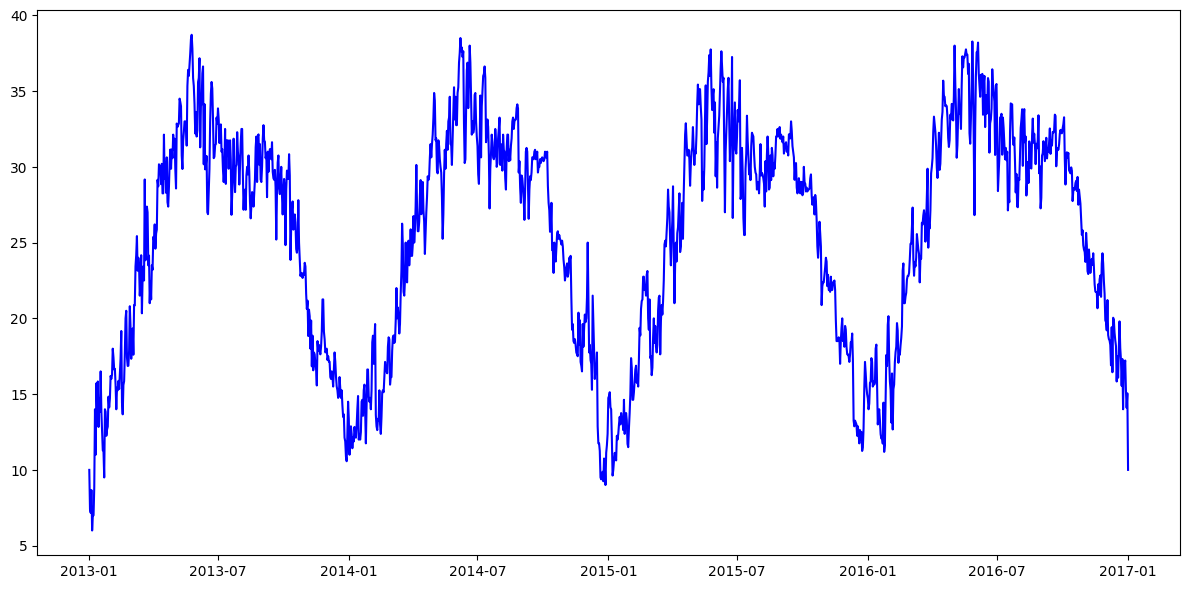

In [199]:
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['meantemp'], color='blue')

plt.tight_layout()
plt.show()

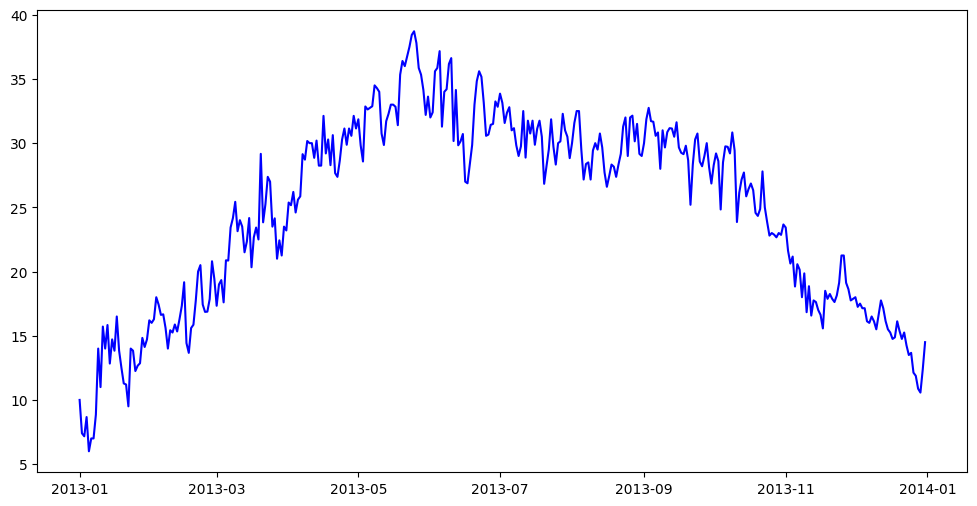

In [200]:
df_2013 = df[df['date'].dt.year == 2013]

plt.figure(figsize=(12,6))
plt.plot(df_2013['date'], df_2013['meantemp'], color='blue')
plt.show()

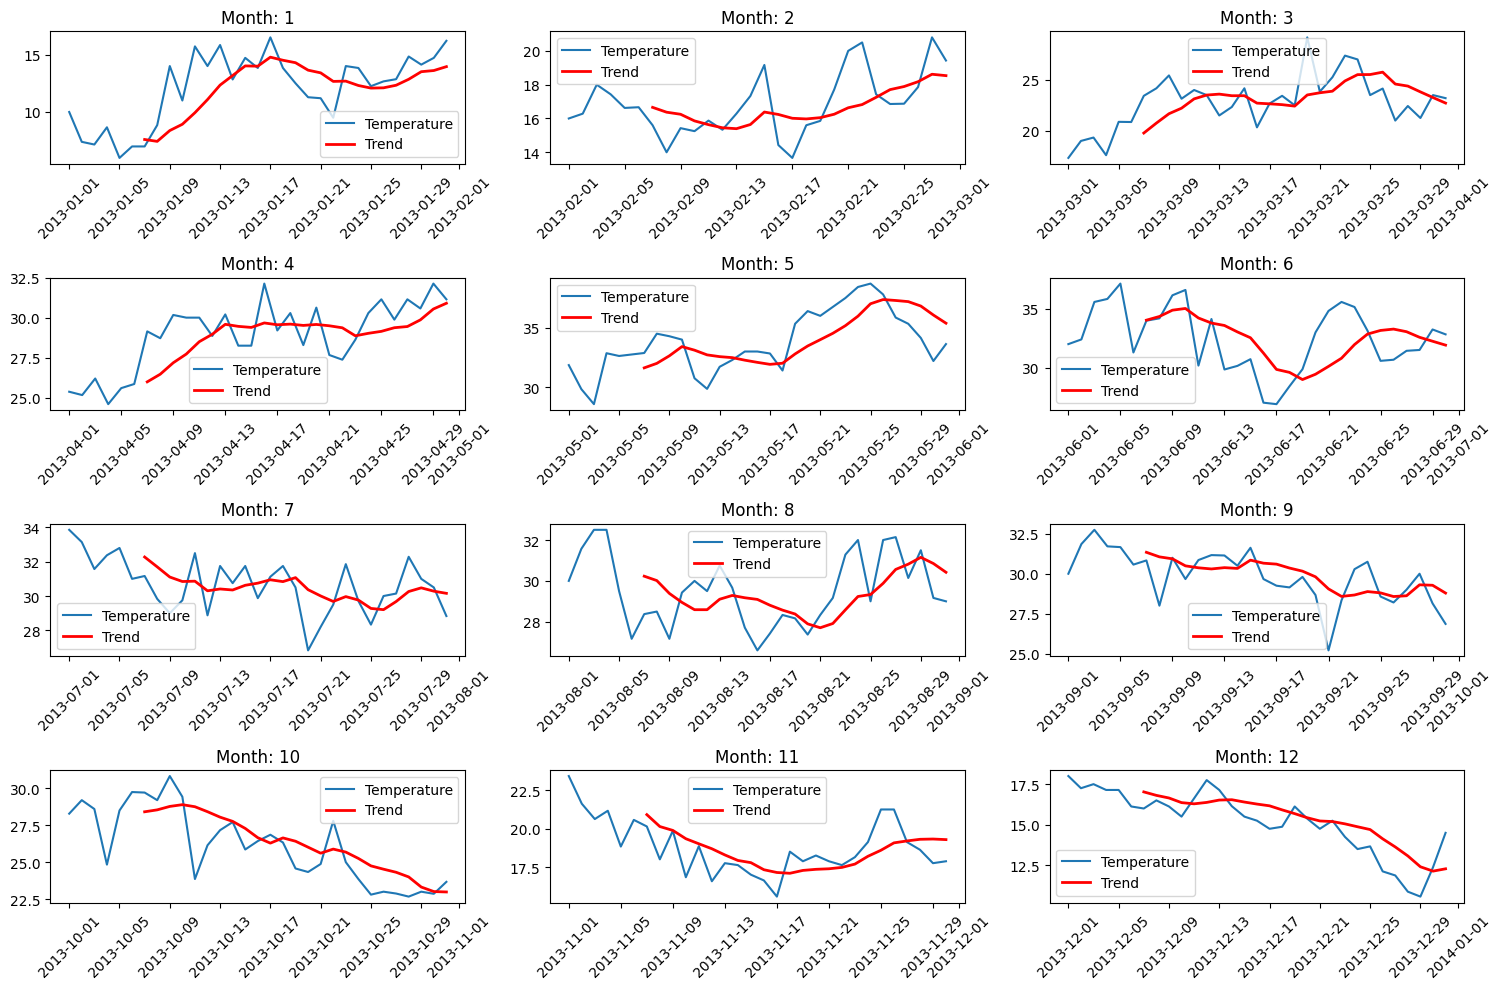

In [201]:
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
axes = axes.flatten()

for month in range(1, 13):
    month_data = df_2013[df_2013['date'].dt.month == month]

    axes[month-1].plot(month_data['date'],month_data['meantemp'],label='Temperature')
    axes[month-1].plot(month_data['date'],month_data['meantemp'].rolling(7).mean(),color='red',linewidth=2,label='Trend')
    axes[month-1].set_title(f'Month: {month}')
    axes[month-1].tick_params(axis='x', rotation=45)
    axes[month-1].legend()

plt.tight_layout()
plt.show()

Intercept: 39.33621193550608
Coefficients: [-0.22980123  0.20243611 -0.00118761]


Text(0.5, 1.0, 'Actual vs Predicted Meantemp')

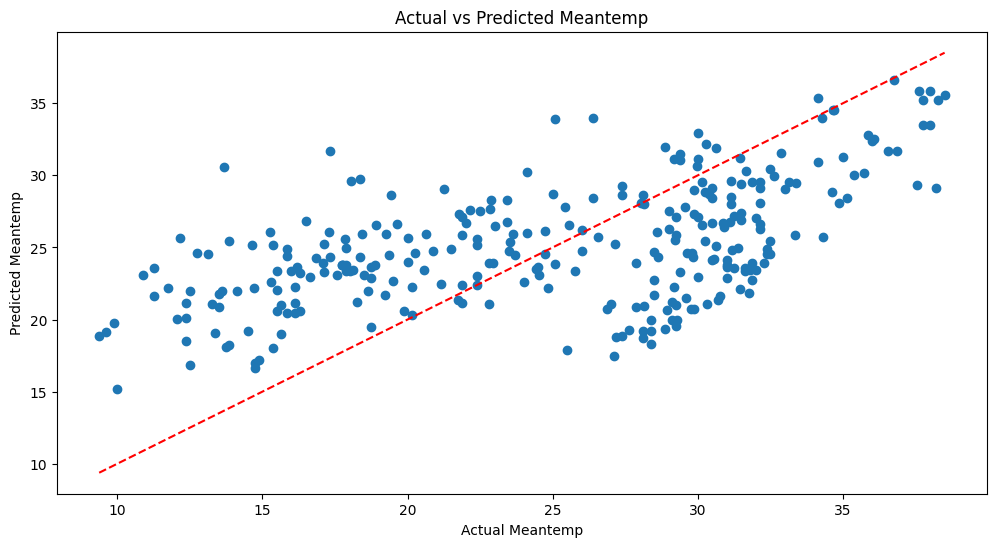

In [202]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X=df[['humidity','wind_speed','meanpressure']]
y=df['meantemp']

X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,Y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

y_pred=model.predict(X_test)

fig=plt.figure(figsize=(12,6))

plt.scatter(Y_test,y_pred)

min_val = min(Y_test.min(), y_pred.min())
max_val = max(Y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect fit')

plt.xlabel('Actual Meantemp')
plt.ylabel('Predicted Meantemp')
plt.title('Actual vs Predicted Meantemp')


Dominant period: 365.50 days


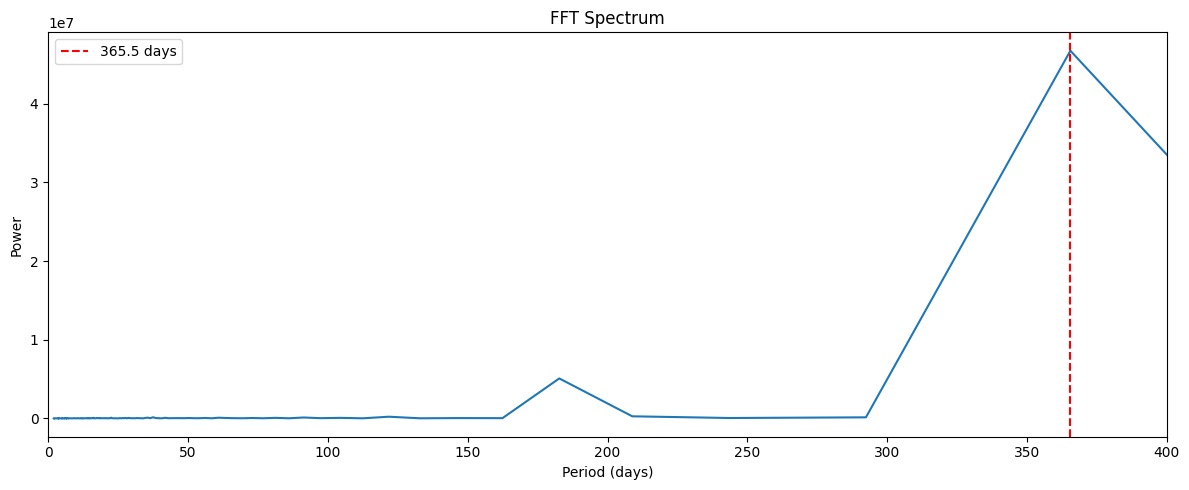

In [203]:
temp = df['meantemp'].dropna().to_numpy()
temp = temp - temp.mean()

fft_values = np.fft.rfft(temp)
freqs = np.fft.rfftfreq(len(temp), d=1)
power = np.abs(fft_values) ** 2

freqs = freqs[1:]
power = power[1:]

idx = np.argmax(power)
dominant_freq = freqs[idx]
dominant_period = 1 / dominant_freq

print(f"Dominant period: {dominant_period:.2f} days")

plt.figure(figsize=(12, 5))
plt.plot(1 / freqs, power)
plt.axvline(dominant_period, color='red', linestyle='--', label=f'{dominant_period:.1f} days')
plt.xlim(0, 400)
plt.xlabel('Period (days)')
plt.ylabel('Power')
plt.title('FFT Spectrum')
plt.legend()
plt.tight_layout()
plt.show()

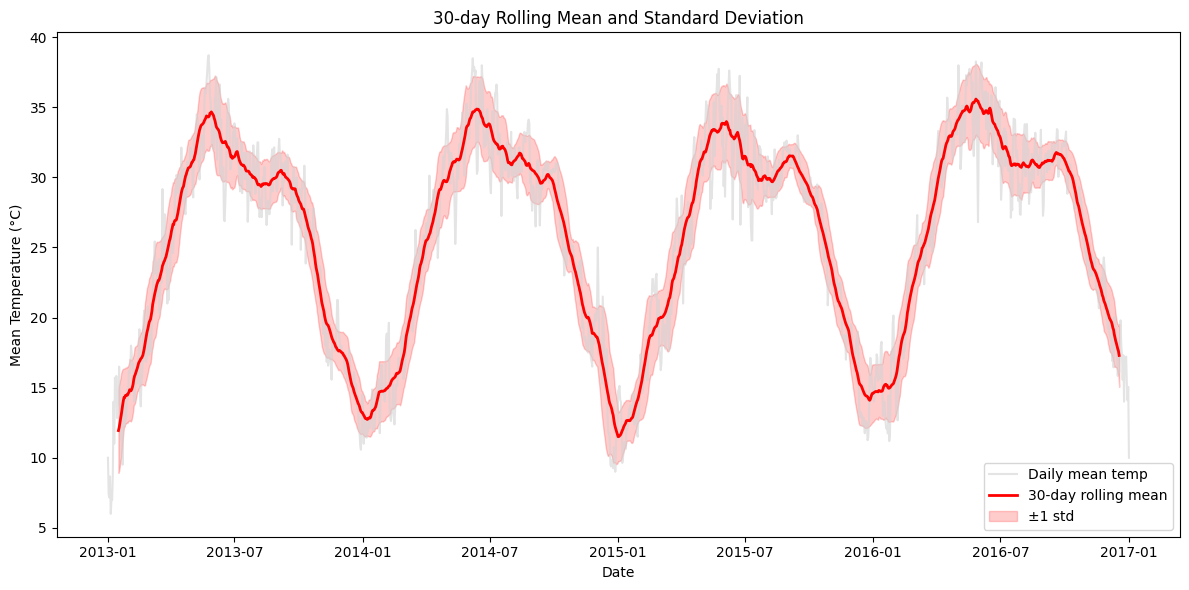

In [ ]:
df_sorted = df.sort_values('date')
temp_series = df_sorted.set_index('date')['meantemp'].dropna()

rolling_mean = temp_series.rolling(window=30, center=True).mean()
rolling_std = temp_series.rolling(window=30, center=True).std()

plt.figure(figsize=(12,6))
plt.plot(temp_series.index, temp_series, color='lightgray', alpha=0.6, label='Daily mean temp')
plt.plot(rolling_mean.index, rolling_mean, color='red', linewidth=2, label='30-day rolling mean')
plt.fill_between(rolling_mean.index, rolling_mean - rolling_std, rolling_mean + rolling_std, color='red', alpha=0.2, label='±1 std')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.title('30-day Rolling Mean and Standard Deviation')
plt.legend()
plt.tight_layout()
plt.show()

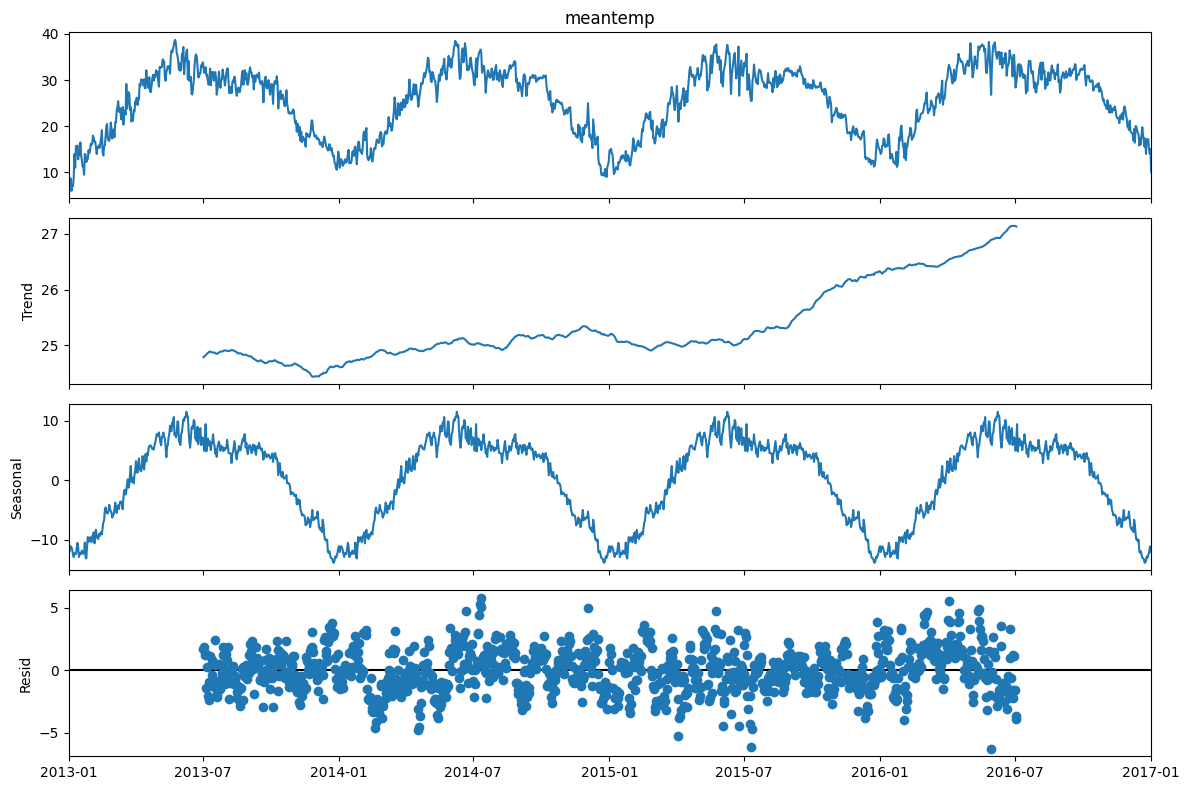

In [204]:
temp_series = df.set_index('date')['meantemp'].dropna()
add_decomp = seasonal_decompose(temp_series, model='additive', period=365)

fig = add_decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

This time series has a 365.5 day seasonality

A slow long-term Trend

Small residuals in range (-5,5)

This is a non-stationary time series, because of the trend component.